# 1D Burgers Equation DEMO code

This notebook demonstrates solving 1D Burgers Equation (spatial xy version) using PINNs.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain

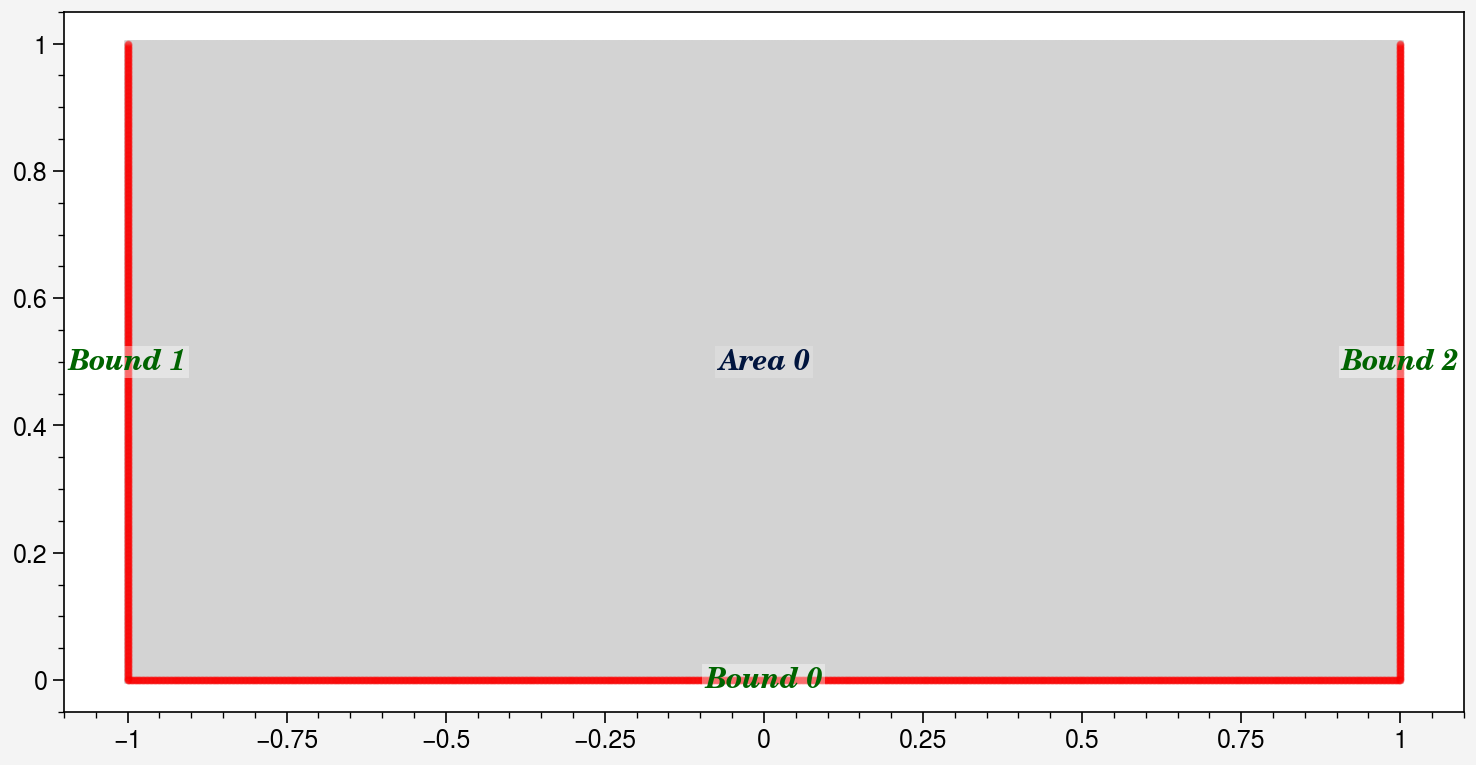

In [2]:
area = df.geometry.rectangle([-1, 1], [0, 1])
line_ic = df.geometry.line_horizontal(y=0, range_x=[-1,1])
line_bc1 = df.geometry.line_vertical(x=-1, range_y=[0,1])
line_bc2 = df.geometry.line_vertical(x=1, range_y=[0,1])
domain = df.domain(area.area_list, line_ic, line_bc1, line_bc2)
domain.show_setup()

## 2. Define Physics
Define the Burgers eq (spatial version) apply boundary conditions.

In [3]:
# Define PDE
from torch import sin, pi
domain.area_list[0].define_pde(df.pde.BurgersEquation1D(nu=0.01/pi))
domain.bound_list[0].define_bc({'u':['x', lambda x: -sin(pi * x)]})
domain.bound_list[1].define_bc({'u': 0})
domain.bound_list[2].define_bc({'u': 0})

### 2. Generate Training Data

Sample initial points for training. After sampling, Deepflow will automatically generate training datasets based on the defined physics.

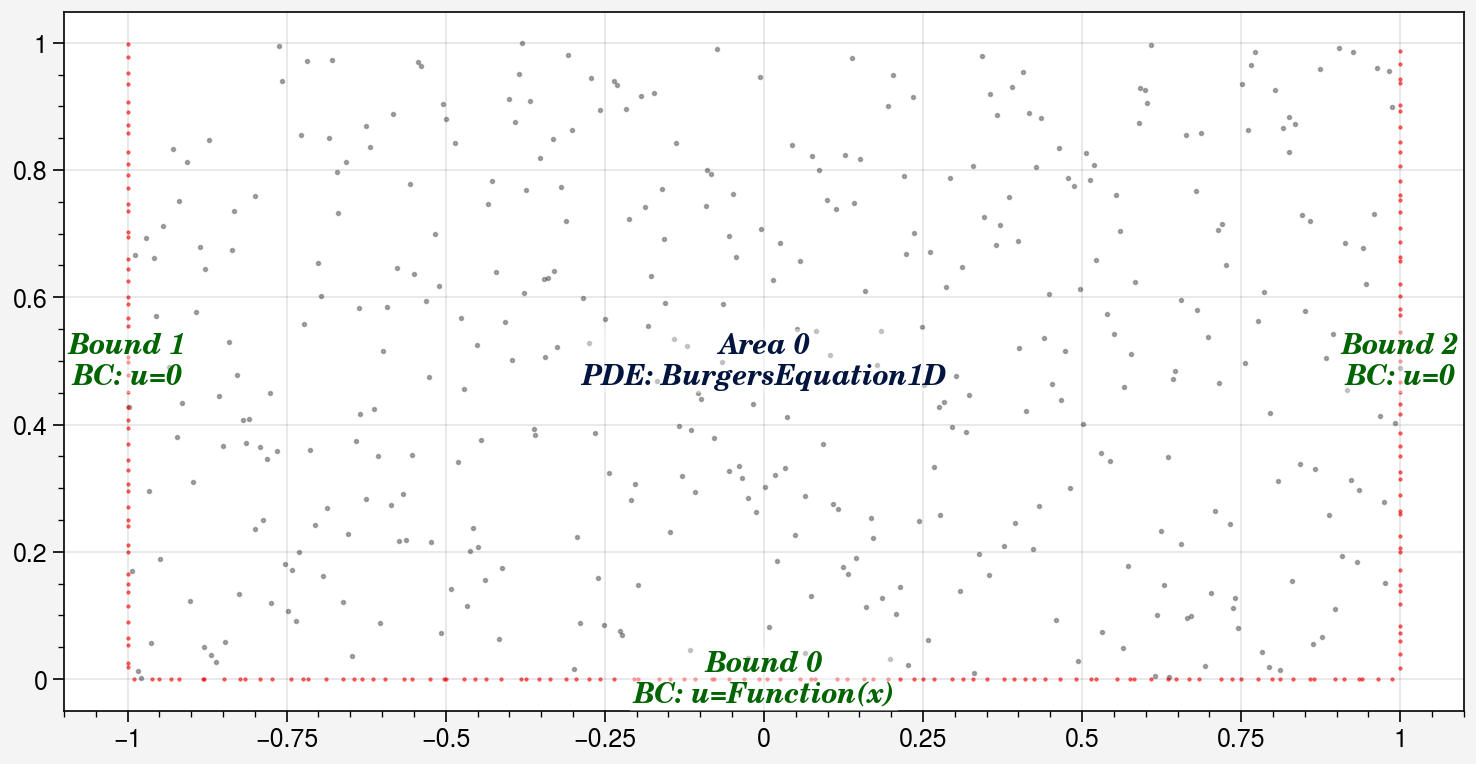

In [4]:
# Sample points: [Left, Bottom, Right, Top], [Interior]
domain.sampling_lhs([100, 50, 50], [400])
domain.show_coordinates(display_physics=True)

### 3. Train the Model

Train the model using Adam optimizer followed by L-BFGS optimizer.

In [5]:
model0 = df.QCPINN(input_vars=['x','y'], output_vars=['u'], hidden_layer_pre=[50], hidden_layer_post=[50], nqubits=5)

model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_simple(domain),
    learning_rate=0.004,
    epochs=1000)

Epoch: 1, total_loss: 0.86363, bc_loss: 0.86332, pde_loss: 0.00032
Epoch: 200, total_loss: 0.10424, bc_loss: 0.05946, pde_loss: 0.04478
Epoch: 400, total_loss: 0.09515, bc_loss: 0.05461, pde_loss: 0.04054
Epoch: 600, total_loss: 0.08836, bc_loss: 0.05059, pde_loss: 0.03777
Epoch: 800, total_loss: 0.07795, bc_loss: 0.04591, pde_loss: 0.03204
Epoch: 1000, total_loss: 0.06284, bc_loss: 0.03912, pde_loss: 0.02372
Epoch: 1000, total_loss: 0.06284, bc_loss: 0.03912, pde_loss: 0.02372


In [ ]:
model2 = model1.train_lbfgs(
    calc_loss = df.calc_loss_simple(domain), 
    epochs=300)

Epoch: 1001, total_loss: 0.06143, bc_loss: 0.03865, pde_loss: 0.02278
Epoch: 1051, total_loss: 0.00545, bc_loss: 0.00290, pde_loss: 0.00255
Epoch: 1101, total_loss: 0.00430, bc_loss: 0.00235, pde_loss: 0.00195
Epoch: 1151, total_loss: 0.00430, bc_loss: 0.00235, pde_loss: 0.00195
Training interrupted by user.


In [ ]:
model2.save_as_pickle('burgers_eq_lhs_model.pkl')

AttributeError: Can't pickle local object 'QCPINN._qnn_setup.<locals>._qnn_layer'

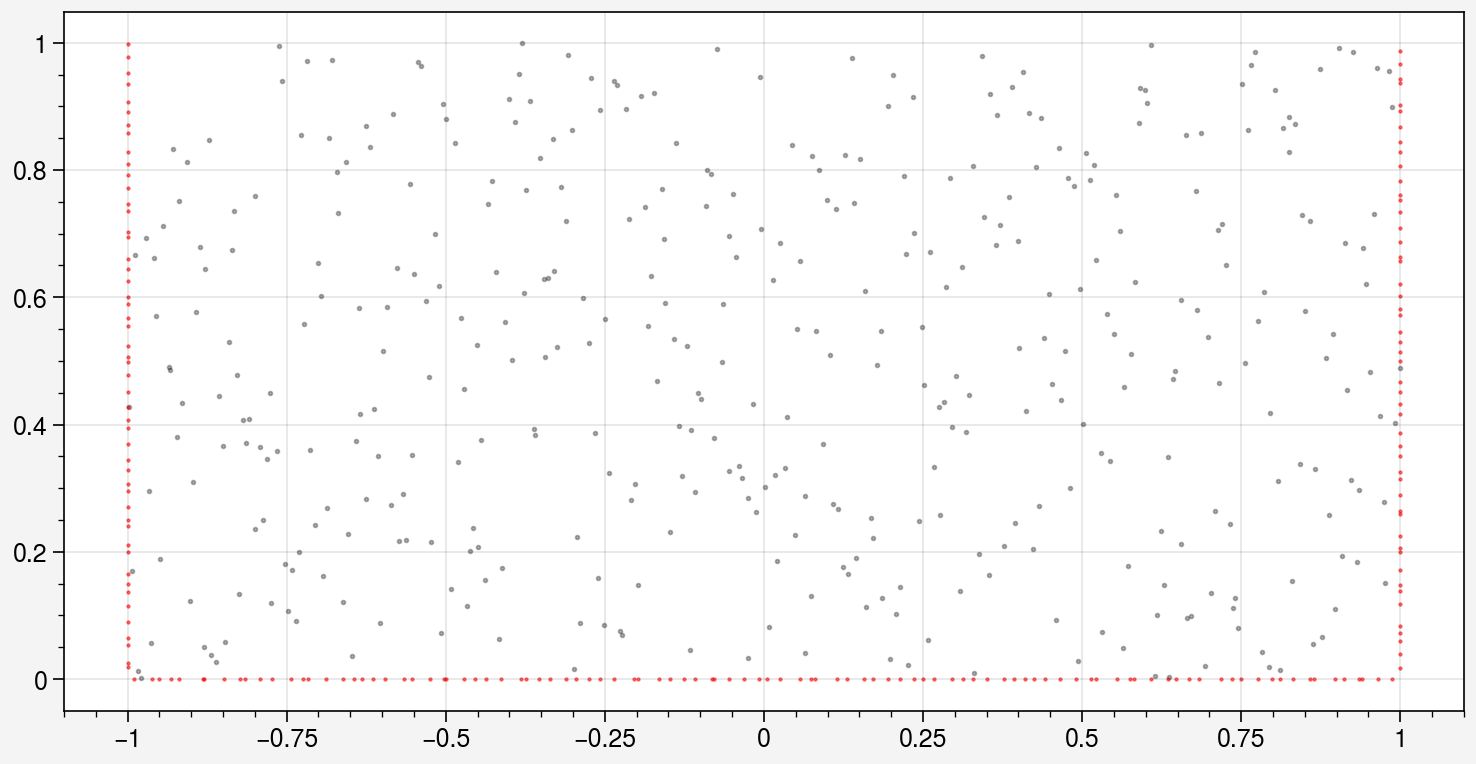

In [7]:
domain.show_coordinates(display_physics=False)

## 4. Visualization

In [8]:
# Evaluate the best model
prediction = domain.area_list[0].evaluate(model2)
# Sampling uniform points
prediction.sampling_area([500, 250])

In [9]:
import numpy as np
prediction["pde_residual"] = np.clip(prediction["pde_residual"],0, 0.5)

### 4.1 Visualize PDE area

C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\events.py:82: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  func(*args, **kwargs)


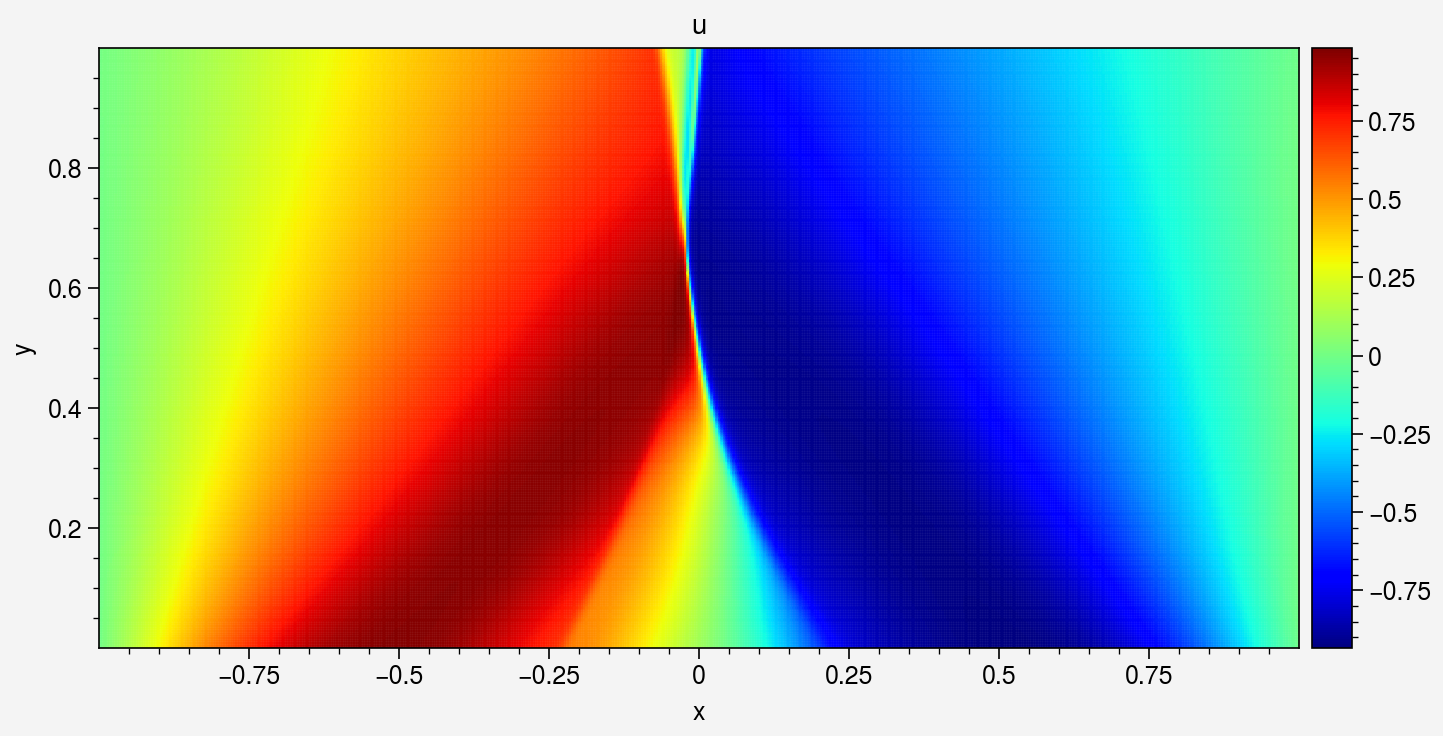

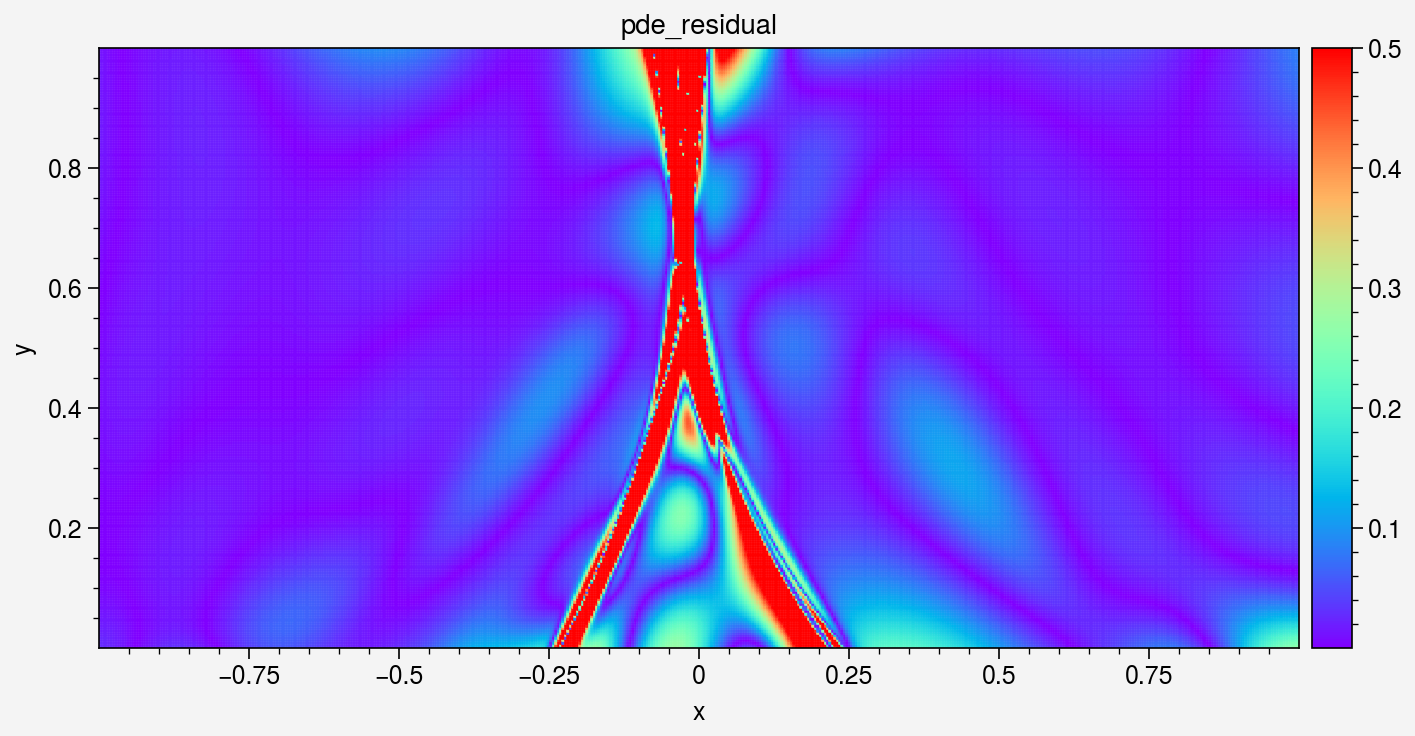

C:\Users\thamm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UltraPlotWarning: Tick label sharing not implemented for <class 'ultraplot.axes.three.ThreeAxes'> subplots.
  fig.canvas.print_figure(bytes_io, **kw)


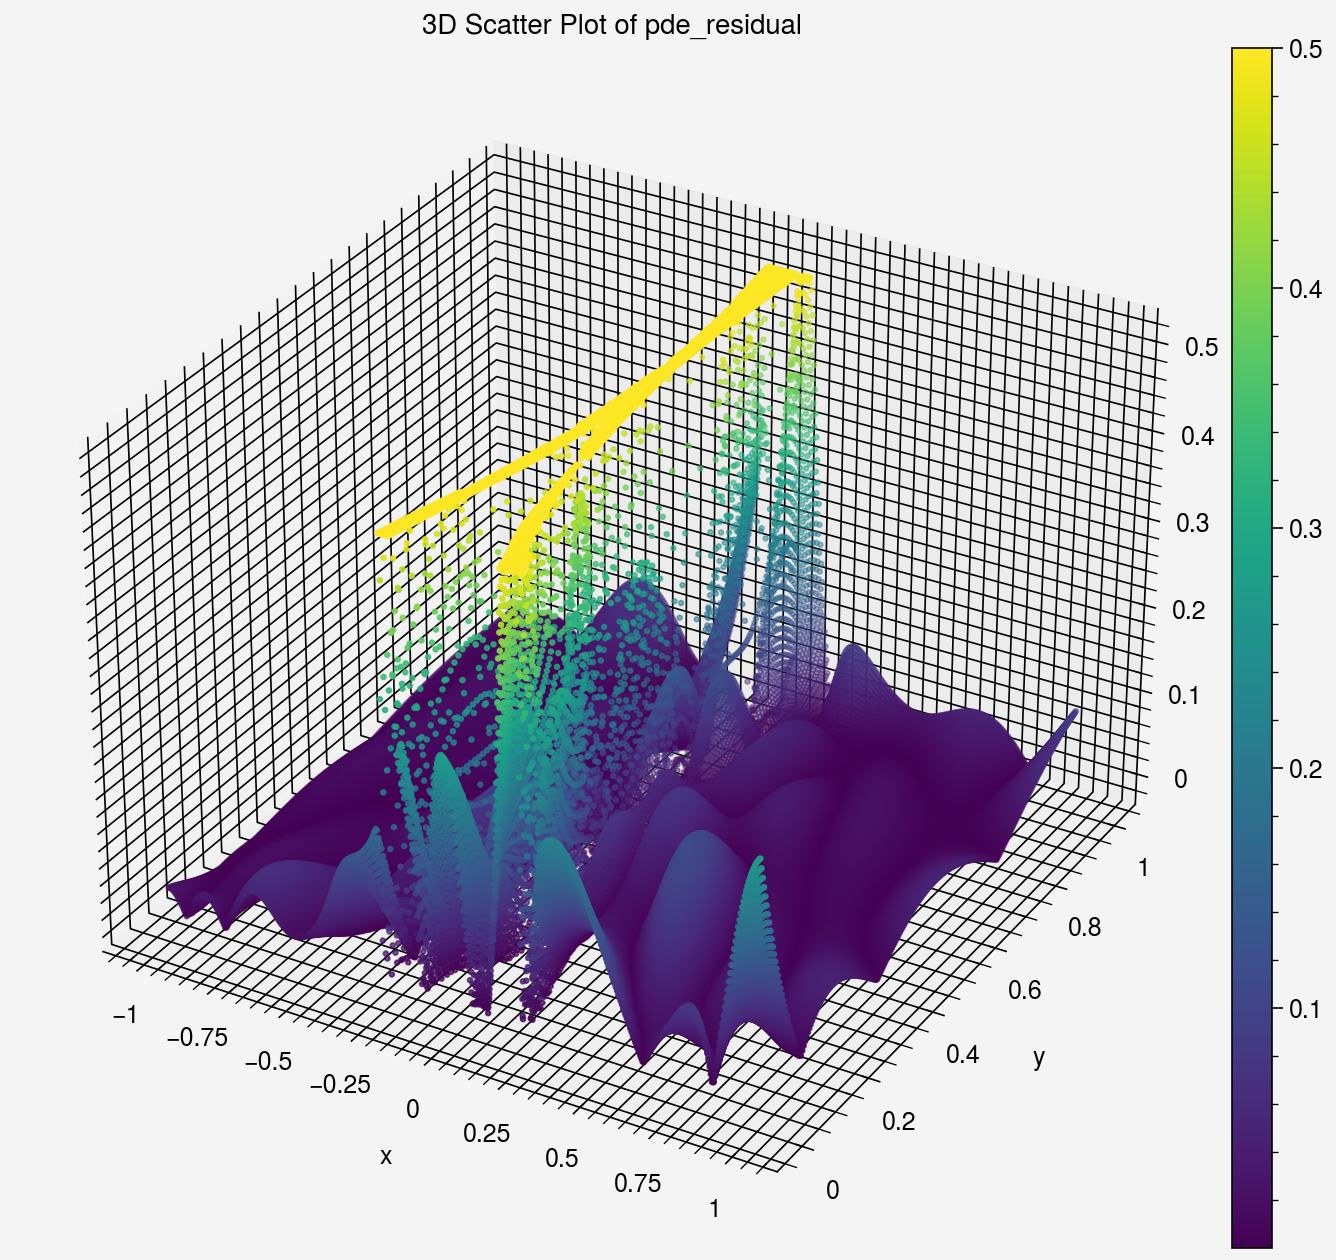

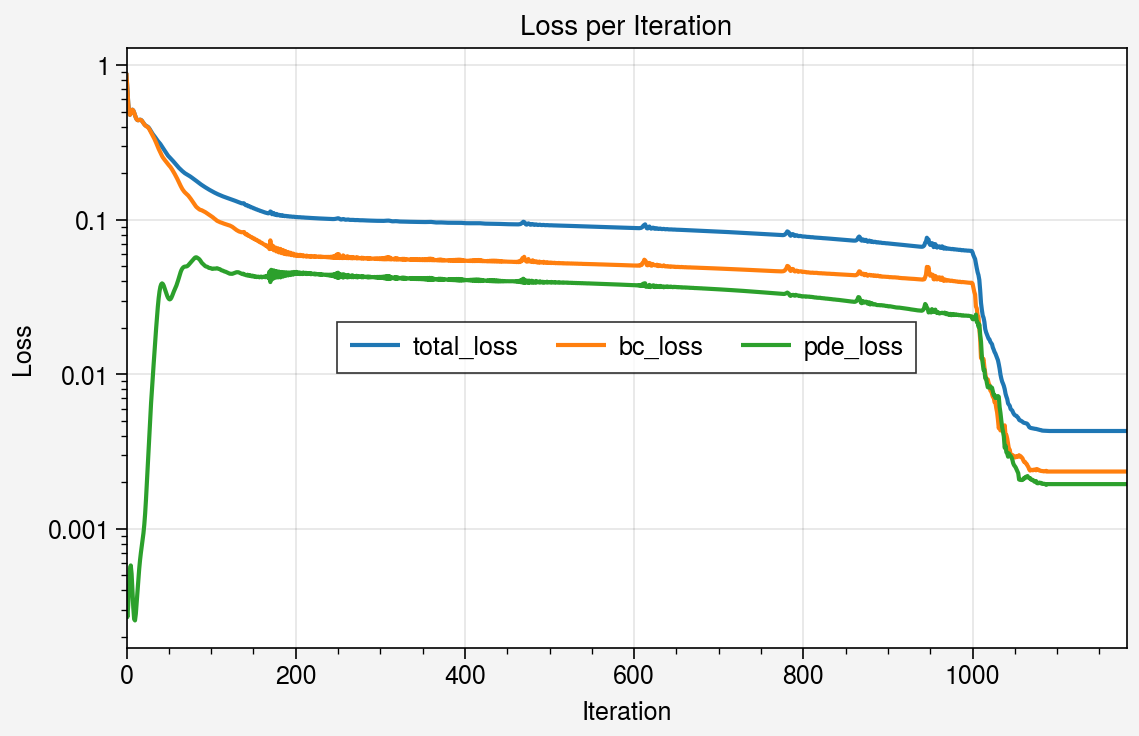

In [10]:
# Plot Velocity Field
prediction.plot_color('u', cmap = 'jet', s=0.3).savefig('u_field.png')
_ = prediction.plot_color('pde_residual', cmap = 'rainbow', s=0.3)
_ = prediction.plot('pde_residual')
_ = prediction.plot_loss_curve(log_scale=True)

### 4.2 Visualize u at y = 0.75

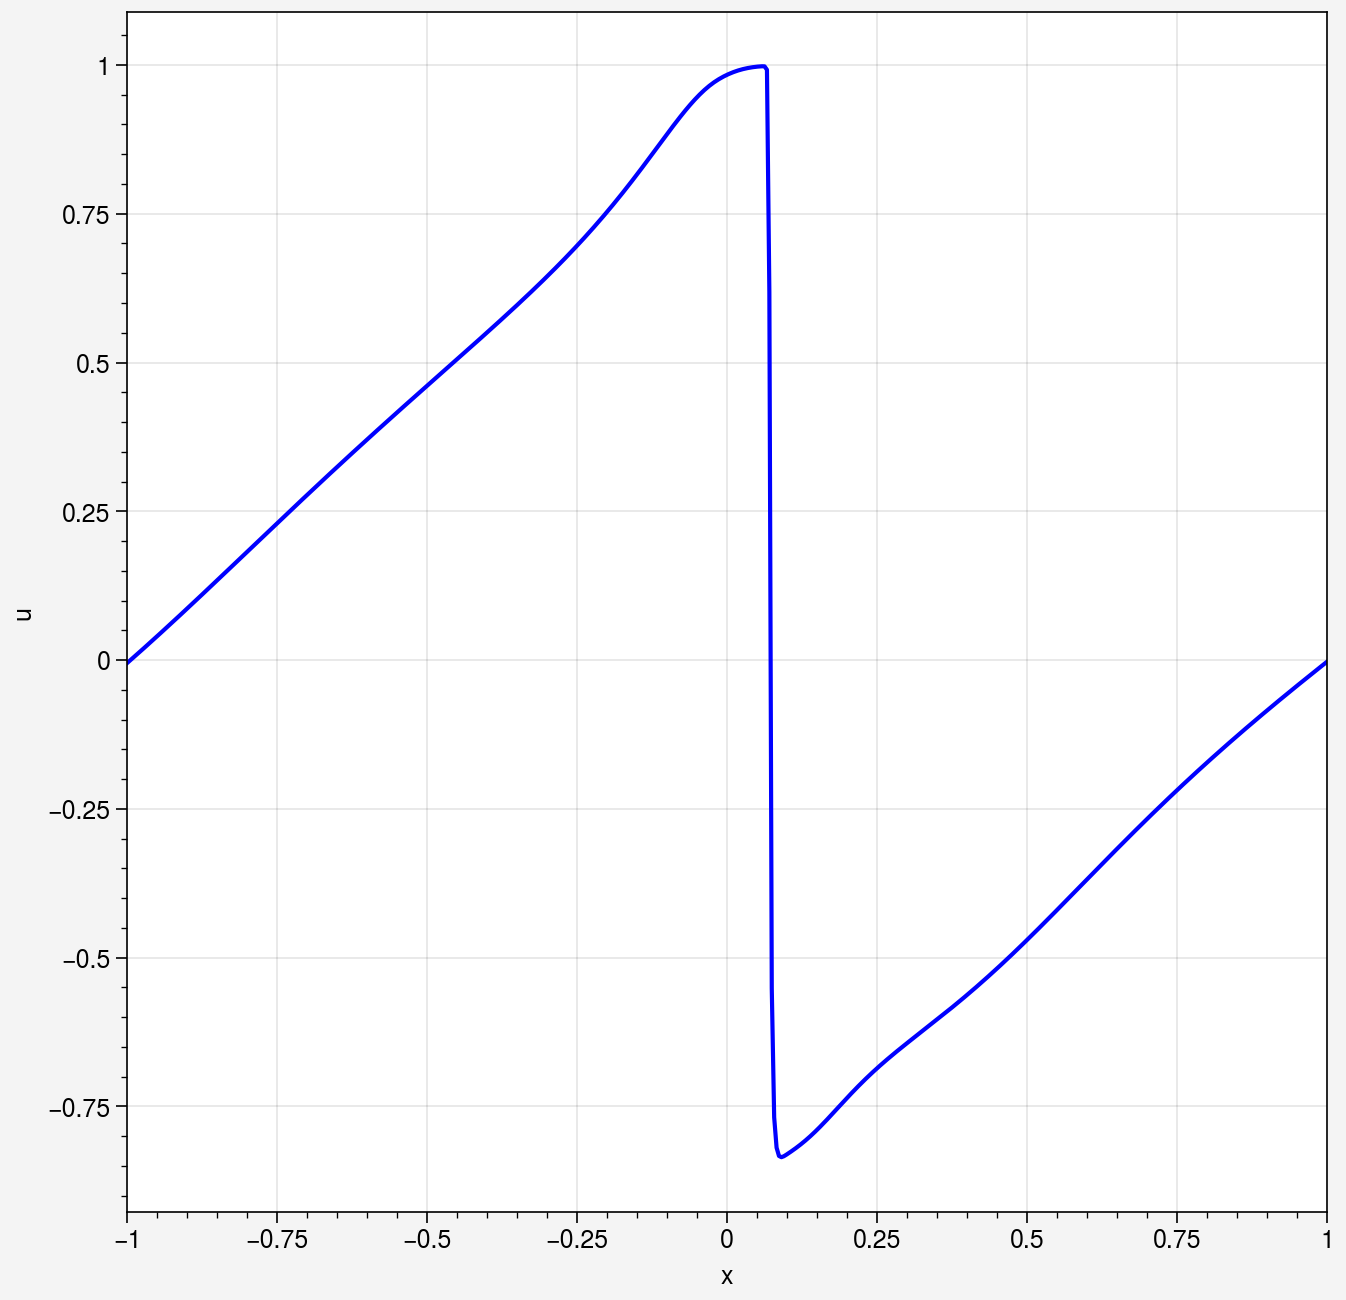

In [ ]:
line = df.geometry.line_horizontal(y=0.75, range_x=[-1, 1])
prediction = line.evaluate(model2)
prediction.sampling_line(500)
_ = prediction.plot(y_axis = 'u')